<div style="font-family: 'Times New Roman', serif; text-align: center; padding: 20px 0;">

<hr style="border: none; border-top: 1px solid #444;">

<p style="font-size: 13px; letter-spacing: 3px; color: #666; margin: 15px 0 8px 0;">
PATCH COMPOSITION
</p>

<p style="font-size: 32px; font-weight: bold; margin: 0 0 15px 0;">
Patch - Parker Solar Probe
</p>

<hr style="border: none; border-top: 1px solid #444; width: 80%;">

</div>

In [12]:
""" Import Modules """
import numpy             as np
import pandas            as pd
import speasy            as spz
import matplotlib.pyplot as plt

from pathlib           import Path
from matplotlib        import rcParams
from scipy.interpolate import interp1d
from scipy             import interpolate, stats
from datetime          import datetime, timedelta

from f_patch import average, load_data_psp

In [13]:
""" Plot Config """
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 13
rcParams['axes.titlesize'] = 18
rcParams['axes.labelsize'] = 15
rcParams['xtick.labelsize'] = 13
rcParams['ytick.labelsize'] = 13
rcParams['legend.fontsize'] = 14
rcParams['figure.titlesize'] = 18

rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['grid.linestyle'] = '--'
rcParams['grid.linewidth'] = 0.5

In [54]:
""" Time Config """
start_PSP = datetime(2023, 3, 17) 
stop_PSP  = datetime(2023, 3, 22)

In [56]:
""" Get Data """ 
data_psp = load_data_psp(start_PSP, stop_PSP)
data_psp

,car_lon,car_lat,r_sun,Np,Na,Vp_r,Vp_t,Vp_n,Tp,Br,Bt,Bn
2023-03-17 00:00:00.374000128,5.437531,-0.599843,0.081268,66.877220,NaN,NaN,NaN,NaN,42.283890,-459.705414,69.701920,33.623768
2023-03-17 00:00:03.868999936,5.439034,-0.599981,0.081266,72.195038,0.388385,216.121811,-8.346628,31.184471,41.848660,-460.499939,66.638847,25.954870
2023-03-17 00:00:07.364000000,5.440536,-0.600119,0.081265,83.939156,0.000000,201.977798,-8.060006,15.134486,41.792698,-460.017914,73.171852,21.049088
2023-03-17 00:00:10.860000000,5.442039,-0.600257,0.081263,83.250435,0.000000,204.622040,-2.734370,-8.305954,47.484131,-461.119751,69.039436,14.263406
2023-03-17 00:00:14.355000064,5.443542,-0.600395,0.081262,88.809814,0.000000,208.022537,-24.612598,27.923014,46.484776,-463.265350,45.751827,24.868830
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-21 23:59:43.468000000,119.335564,0.918492,0.214444,76.224121,3.501706,360.802216,-8.256701,-60.060207,32.087482,74.024719,-36.325077,24.786364
2023-03-21 23:59:46.963000064,119.335284,0.918511,0.214446,40.920841,2.659405,381.860657,9.809798,-83.527184,38.189163,62.699501,-55.096523,23.187294
2023-03-21 23:59:50.457999872,119.335005,0.918530,0.214447,26.616686,2.548963,393.007019,0.222193,-74.338402,48.014660,43.644829,-71.244545,11.346334
2023-03-21 23:59:53.953999872,119.334726,0.918550,0.214449,32.191895,2.841701,377.198639,8.484336,-78.265747,40.376125,61.714859,-55.199421,19.655468


In [57]:
""" Derived parameters """
alpha_percent_psp = data_psp['Na'] / (data_psp['Na'] + data_psp['Np']) * 100

In [58]:
""" Averaged quantities """
Vp_r_psp_average = average(data_psp['Vp_r'], 100)

Np_avrg = average(data_psp['Np'], 100)

alpha_percent_avrg = average(alpha_percent_psp, 100)

Text(1.08, 0.5, '— $r$ $[AU]$')

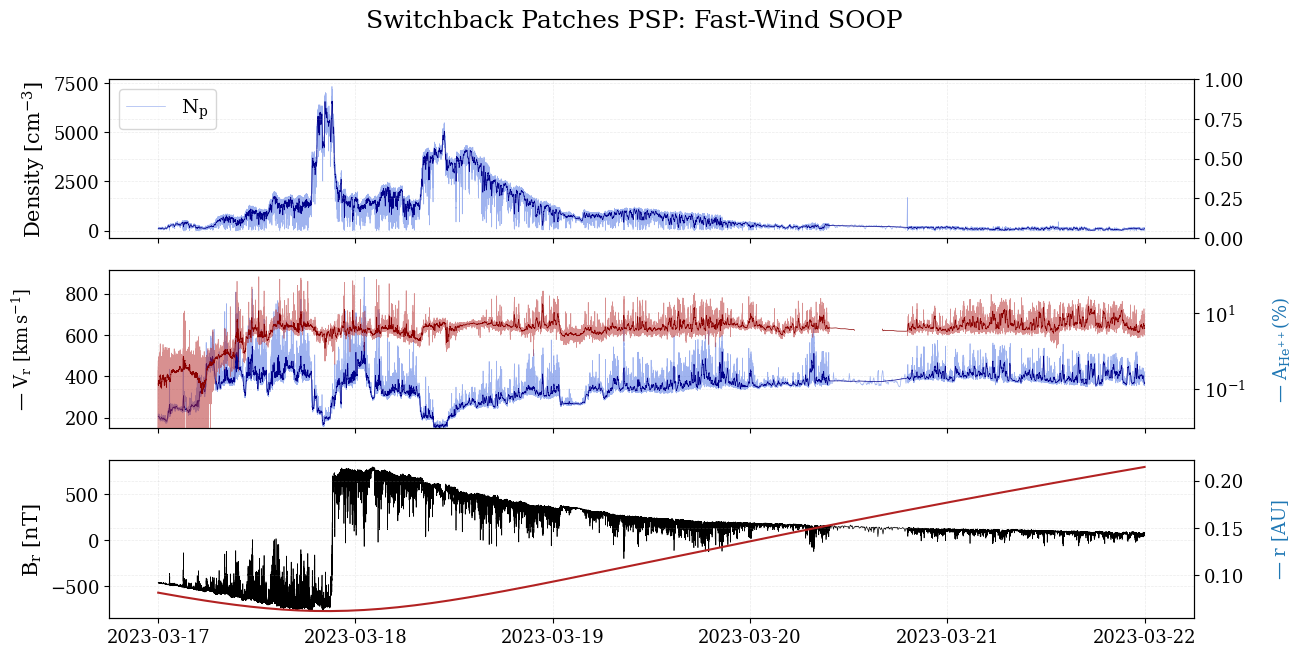

In [59]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(14,7))
fig.suptitle("Switchback Patches PSP: Fast-Wind SOOP")

plt.rcParams["mathtext.default"] = "regular"

time_index = data_psp.index

ax1b = ax1.twinx()
ax1.plot(time_index, data_psp['Np'], label='$N_p$', color='royalblue', linewidth='0.5', alpha=0.5)
ax1.plot(time_index, Np_avrg, color='darkblue', linewidth='0.5')
# ax1b.plot(Na_PSP.index, Na_PSP.iloc[:,0], label='$N_a$', color='tab:red', linewidth='0.5', alpha=0.8)
ax1.legend(loc='upper left')
# ax1b.legend(loc='upper right')
ax1.set_ylabel('Density $[cm^{-3}]$')

# --- Vr / A%
ax2.plot(time_index, data_psp['Vp_r'], label='$V_p$', color='royalblue', linewidth='0.5', alpha=0.5)
ax2.plot(time_index, Vp_r_psp_average, color='darkblue', linewidth='0.5')

ax2b = ax2.twinx()
ax2b.plot(time_index, alpha_percent_psp, label=r'$\alpha _{\%}$', color='firebrick', linewidth=0.5, alpha=0.5)
ax2b.plot(time_index, alpha_percent_avrg ,color='darkred', linewidth=0.5)

ax2b.set_yscale('log')
ax2.annotate(
    r'— $V_r$ $[km\,s^{-1}]$',
    xy=(-0.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='black')
ax2.set_ylim(150, None)

ax2b.annotate(
    r'— $A_{He^{++}} (\%)$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')

ax3b = ax3.twinx()
ax3.plot(time_index, data_psp['Br'], color ='black', linewidth='0.5')
ax3b.plot(time_index, data_psp['r_sun'], color='firebrick')
ax3.set_ylabel('$B_r$ $[nT]$')
ax3b.annotate(
    r'— $r$ $[AU]$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')
# ax3b.set_ylim(None,0.2)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - PSP
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Angular Displacement
</p>

</div>

In [64]:
""" Ephemeris Data """ #TODO Corriger cela
# phi, theta, psp_r_sun = data_psp['car_lon'], data_psp['car_lat'], data_psp['r_sun']

' Ephemeris Data '

In [65]:
from f_patch import _load_data_ephemeris_psp
data = _load_data_ephemeris_psp(start_PSP, stop_PSP)

Vp_rtn_PSP = spz.get_data("amda/psp_spi_Hv", start_PSP, stop_PSP).to_dataframe()
Vp_r_PSP, Vp_t_PSP, Vp_n_PSP = Vp_rtn_PSP['vr'], Vp_rtn_PSP['vt'], Vp_rtn_PSP['vn']

In [69]:
phi, theta, psp_r_sun = data['car_lon'], data['car_lat'], data['r_sun']

In [71]:
t_coord = phi.index

phi_rad   = phi * np.pi/180
theta_rad = theta * np.pi/180

phi_rad_new   = phi_rad#['lon iau_sun']
theta_rad_new = theta_rad#['lat iau_sun']

t_coord_float = t_coord.astype(np.int64) / 1e9
df_time_float = Vp_rtn_PSP.index.astype(np.int64) / 1e9

interp_theta = interp1d(t_coord_float, theta_rad_new, kind='linear', bounds_error=False, fill_value="extrapolate")
interp_phi   = interp1d(t_coord_float, phi_rad_new,   kind='linear', bounds_error=False, fill_value="extrapolate")

theta_z = interp_theta(df_time_float)
phi_z   = interp_phi(df_time_float)

dtheta = np.diff(theta_z)
dphi   = np.diff(phi_z)

ds_psp    = np.sqrt(dtheta**2 + (np.cos(theta_z[:-1]) * dphi)**2)
s_psp     = np.concatenate([[0], np.cumsum(ds_psp)])
s_psp_deg = np.degrees(s_psp)

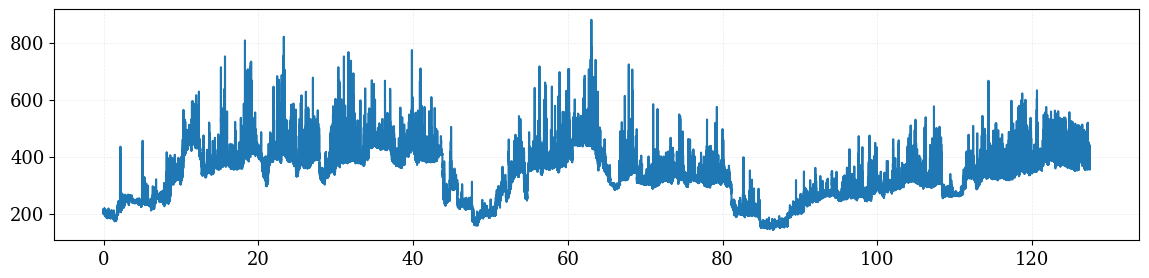

In [73]:
plt.figure(figsize=(14,3))
plt.plot(s_psp_deg, Vp_rtn_PSP['vr'])

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - PSP
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Fourier Analysis
</p>

</div>

In [109]:
f_cut = 9.3e-2

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Velocity

In [112]:
Vp_rtn_PSP.loc[np.isnan(Vp_rtn_PSP['vr']), "vr"] = np.mean(Vp_rtn_PSP['vr'])

# --- Regular sampling ---
s_psp_new = np.linspace(0, max(s_psp_deg), int(max(s_psp_deg)/min(np.diff(s_psp_deg))))

v_r_interp = interp1d(s_psp_deg, Vp_rtn_PSP['vr'], kind='linear', bounds_error=False, fill_value="extrapolate")
v_r_new = v_r_interp(s_psp_new)

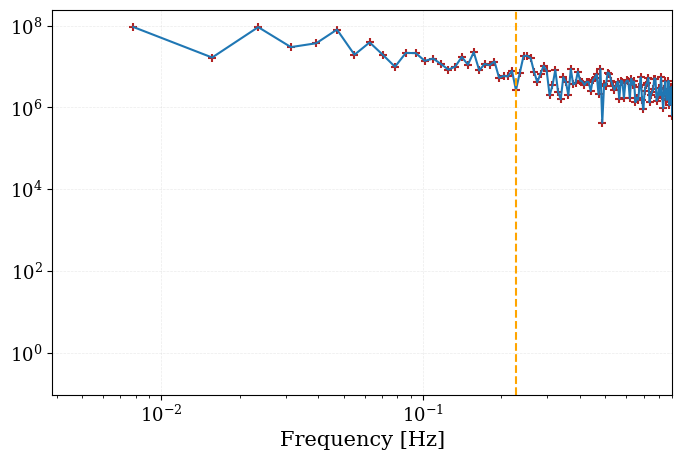

In [114]:
# --- velocity
ds_vr = np.mean(np.diff(s_psp_new))

fft_vr  = np.fft.rfft(v_r_new)
freq_vr = np.fft.rfftfreq(len(v_r_new), d=ds_vr)

plt.figure(figsize=(8,5))

plt.loglog(freq_vr[1:], np.abs(fft_vr[1:]))
plt.scatter(
    freq_vr[1:],
    np.abs(fft_vr[1:]),
    marker='+',
    color='firebrick'
)

plt.axvline(
    freq_vr[29],
    color="orange",
    linestyle="--"
)

plt.xlabel("Frequency [Hz]")

plt.xlim(None, 9e-1)

# plt.savefig(Path('..') / f"Results/Figures/spectrum_{start_PSP.strftime("%Y-%m-%d")}_{stop_PSP.strftime("%Y-%m-%d")}.png")
plt.show()

In [115]:
idx_cut_vr = np.argmin(np.abs(freq_vr - f_cut))

fft_vr[idx_cut_vr:] = 0.0

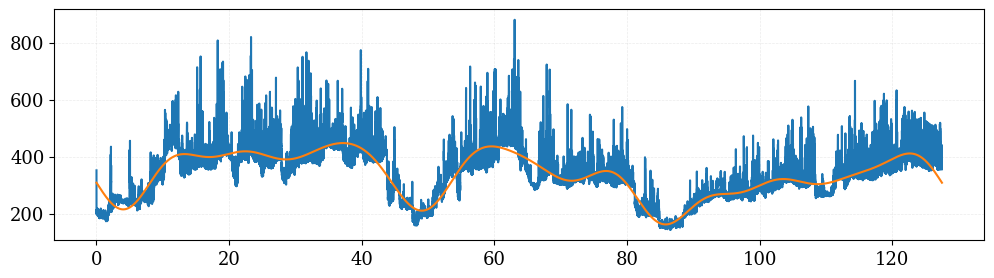

In [116]:
filter_data_vr = np.fft.irfft(fft_vr)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_psp_new, v_r_new)
ax.plot(s_psp_new[:-1], filter_data_vr)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Alpha Abundance

In [118]:
Np_PSP = spz.get_data("amda/psp_spi_Hn", start_PSP, stop_PSP).to_dataframe()
Na_PSP = spz.get_data("amda/psp_spi_an", start_PSP, stop_PSP).to_dataframe()
    
alpha_abundance_PSP = (Na_PSP.iloc[:,0] / (Na_PSP.iloc[:,0] + Np_PSP.iloc[:,0])) * 100

In [119]:
alpha_percent = pd.DataFrame(alpha_abundance_PSP)
alpha_percent.columns = ["a_percent"]

In [120]:
alpha_percent.loc[np.isnan(alpha_percent['a_percent']), "a_percent"] = np.mean(alpha_percent['a_percent'])

# --- Regular sampling ---
a_percent_interp = interp1d(s_psp_deg, alpha_percent['a_percent'], kind='linear', bounds_error=False, fill_value="extrapolate")
a_percent_new = a_percent_interp(s_psp_new)

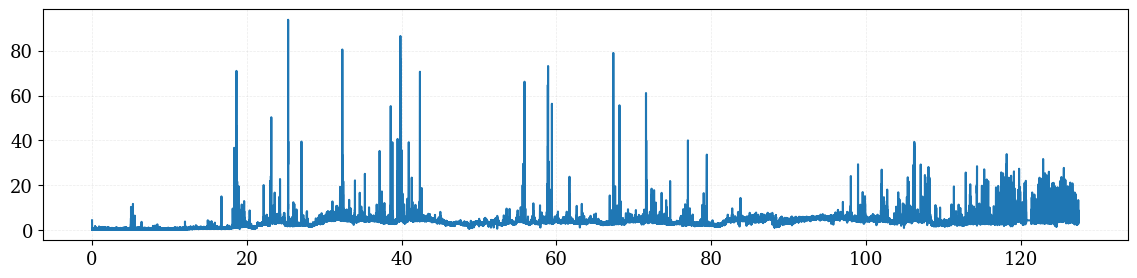

In [123]:
plt.figure(figsize=(14, 3))
plt.plot(s_psp_new, a_percent_new)

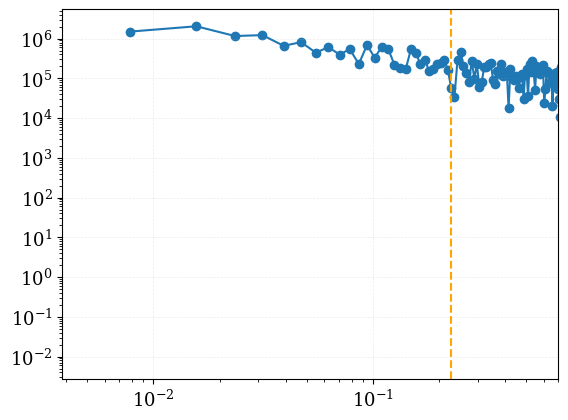

In [124]:
# --- alpha abundance
ds_a_percent = np.mean(np.diff(s_psp_new))

fft_a_percent  = np.fft.rfft(a_percent_new)
freq_a_percent = np.fft.rfftfreq(len(a_percent_new), d=ds_a_percent)

plt.loglog(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
plt.scatter(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
plt.axvline(
    freq_a_percent[29],
    color="orange",
    linestyle="--"
)
plt.xlim(None, 7e-1)
plt.show()

In [125]:
idx_cut_a_percent = np.argmin(np.abs(freq_a_percent - f_cut))

fft_a_percent[idx_cut_a_percent:] = 0.0

(0.0, 30.0)

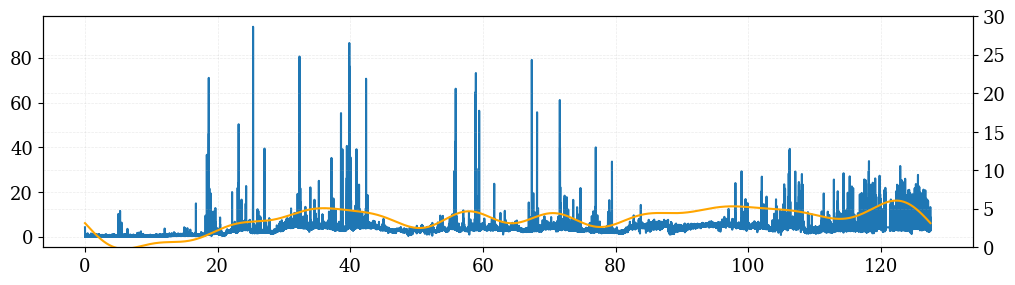

In [126]:
filter_data_a_percent = np.fft.irfft(fft_a_percent)
fig, ax = plt.subplots(figsize=(12, 3))
axb = ax.twinx()
ax.plot(s_psp_new, a_percent_new)
axb.plot(s_psp_new[:-1], filter_data_a_percent, color='orange')
axb.set_ylim(0, 30)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - PSP
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Correlation
</p>

</div>

In [128]:
r_a_vr, p_a_vr = stats.pearsonr(filter_data_vr, filter_data_a_percent)

In [129]:
r_a_vr

np.float64(0.08788075676381801)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - PSP
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Figures
</p>

</div>

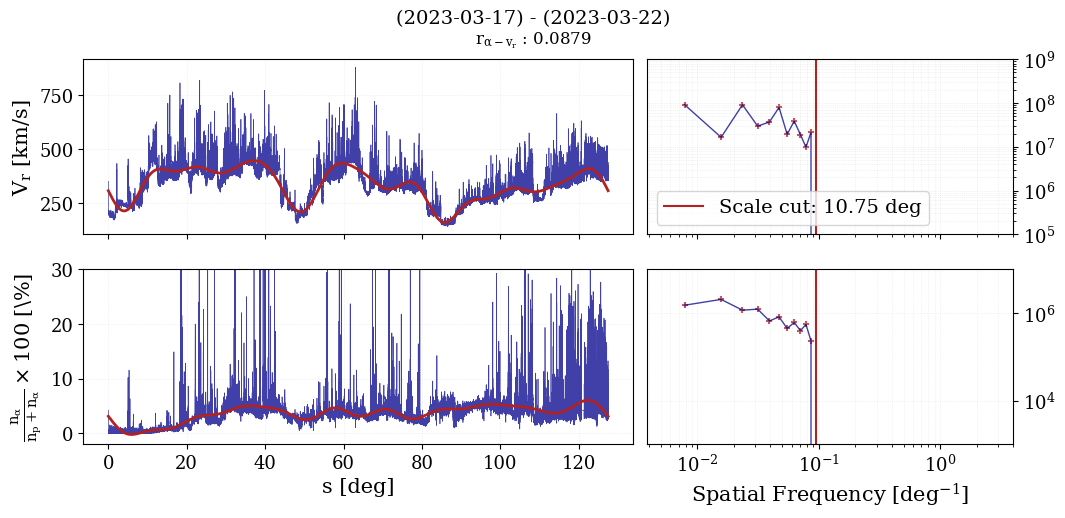

In [135]:
fig = plt.figure(figsize=(12, 5))

gs = fig.add_gridspec(2, 2, width_ratios=[1.5, 1], wspace=0.03, hspace=0.2)

fig.suptitle(
    rf"({start_PSP.strftime('%Y-%m-%d')}) - ({stop_PSP.strftime('%Y-%m-%d')})",
    fontsize=14
)

fig.text(
    0.5, 0.94,
    rf"$r_{{\alpha-v_r}}$ : {r_a_vr:.4f}",
    ha="center",
    va="top",
    fontsize=12
)

# Left column: time series
ax_v = fig.add_subplot(gs[0, 0])
ax_a = fig.add_subplot(gs[1, 0], sharex=ax_v)

# Right column: spectra
ax_v_spec = fig.add_subplot(gs[0, 1])
ax_a_spec = fig.add_subplot(gs[1, 1])#, sharex=ax_v_spec)

# Velocity time series
ax_v.plot(s_psp_new, v_r_new, color = 'darkblue', linewidth=0.5, alpha=0.75)
ax_v.plot(s_psp_new[:-1], filter_data_vr, linewidth=2.0, color='firebrick')
ax_v.set_ylabel(r"$V_r$ [$km/s$]")
ax_v.tick_params(labelbottom=False)
ax_v.grid(which="both", linestyle=":", alpha=0.3)

# Velocity spectrum
ax_v_spec.loglog(freq_vr[1:], np.abs(fft_vr[1:]), linewidth=1, color='darkblue', alpha=0.75)
ax_v_spec.scatter(freq_vr[1:], np.abs(fft_vr[1:]), marker="+", color="firebrick", s=20, alpha=0.75)
ax_v_spec.axvline(freq_vr[idx_cut_vr], color="firebrick", linestyle="-", linewidth=1.5, label=f"Scale cut: {round(1/f_cut, 2)} deg")
ax_v_spec.set_xlim(None, 4e0)
ax_v_spec.set_ylim(1e5, 1e9)
ax_v_spec.grid(which="both", linestyle=":", alpha=0.3)
ax_v_spec.tick_params(labelbottom=False)
ax_v_spec.legend(loc="lower left")

# Alpha abundance time series
ax_a.plot(s_psp_new, a_percent_new, linewidth=0.5, color='darkblue', alpha=0.75)
ax_a.plot(s_psp_new[:-1], filter_data_a_percent, color="firebrick", linewidth=2.0)
ax_a.set_ylabel(r"$\frac{n_\alpha}{n_p+n_\alpha}\times100$ [\%]")
ax_a.set_xlabel("s [deg]")
ax_a.set_ylim(-2, 30)
ax_a.grid(which="both", linestyle=":", alpha=0.3)

# Alpha spectrum
ax_a_spec.loglog(freq_a_percent[1:], np.abs(fft_a_percent[1:]), linewidth=1, color='darkblue', alpha=0.75)
ax_a_spec.scatter(freq_a_percent[1:], np.abs(fft_a_percent[1:]), marker="+", color="firebrick", s=20, alpha=0.75)
ax_a_spec.axvline(freq_a_percent[idx_cut_a_percent], color="firebrick", linestyle="-", linewidth=1.5)
ax_a_spec.set_xlabel("Spatial Frequency [$deg^{-1}$]")
ax_a_spec.set_xlim(None, 4e0)
ax_a_spec.set_ylim(1e3, 1e7)
ax_a_spec.grid( which="both", linestyle=":", alpha=0.3)

ax_v_spec.yaxis.tick_right()
ax_v_spec.yaxis.set_label_position("right")

ax_a_spec.yaxis.tick_right()
ax_a_spec.yaxis.set_label_position("right")

# Save
fig.savefig(
    Path("..") / "Results" / "Figures" /
    f"PSP-corr_{start_PSP.strftime('%Y-%m-%d')}_"
    f"{stop_PSP.strftime('%Y-%m-%d')}_"
    f"{round(1/f_cut, 2)}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()